#  Load packages

In [2]:
# skip reinstalling packages we already have
using Pkg

pkgs = [
    "MLJ", "MLJBase", "MLJModels", "MLJEnsembles", "MLJLinearModels",
    "DecisionTree", "MLJDecisionTreeInterface", "NaiveBayes", 
    "MLJNaiveBayesInterface", "EvoTrees", "CategoricalArrays", "Random",
    "LIBSVM", "MLJLIBSVMInterface", "Plots", "MLJModelInterface",
    "CSV", "DataFrames", "UrlDownload", "XGBoost","MultivariateStats"
]

# Filter out packages already installed
missing_pkgs = filter(pkg -> !(pkg in keys(Pkg.project().dependencies)), pkgs)

if !isempty(missing_pkgs)
    println("Installing missing packages: ", missing_pkgs)
    Pkg.add(missing_pkgs)
else
    println(" All required packages are already installed.")
end


 All required packages are already installed.


# Import packages

In [3]:
using CSV, DataFrames, Random
using Flux
using CategoricalArrays
using Plots
using Random
using Statistics
#Load your library of functions
include("utils.2.0.jl")
# Set a global random seed for reproducibility
Random.seed!(42)

# --- Accuracy function ---
#accuracy(pred::Vector{Int}, truth::Vector{Int}) = mean(pred .== truth)

TaskLocalRNG()

# Functions

In [4]:
function trainClassANN(topology::AbstractArray{<:Int,1},  
            trainingDataset::Tuple{AbstractArray{<:Real,2}, AbstractArray{Bool,2}}; 
            # --- Requirement: optional validation dataset with default empty arrays ---
            validationDataset::Tuple{AbstractArray{<:Real,2}, AbstractArray{Bool,2}}= 
                    (Array{eltype(trainingDataset[1]),2}(undef,0,0), falses(0,0)), 
            # --- Requirement: optional test dataset with default empty arrays ---
            testDataset::Tuple{AbstractArray{<:Real,2}, AbstractArray{Bool,2}}= 
                    (Array{eltype(trainingDataset[1]),2}(undef,0,0), falses(0,0)), 
            transferFunctions::AbstractArray{<:Function,1}=fill(σ, length(topology)), 
            maxEpochs::Int=1000, minLoss::Real=0.0, learningRate::Real=0.01,  
            # --- Requirement: maxEpochsVal parameter (early stopping patience), default 20 ---
            maxEpochsVal::Int=20, showText::Bool=false) 

    # --- Unpacking datasets ---
    (inputs, targets) = trainingDataset
    (val_inputs, val_targets) = validationDataset
    (test_inputs, test_targets) = testDataset

    # --- Ensures dataset dimensions match ---
    @assert size(inputs,1) == size(targets,1)
    @assert size(val_inputs,1) == size(val_targets,1)
    @assert size(test_inputs,1) == size(test_targets,1)

    # --- Requirement: build ANN with given topology ---
    ann = buildClassANN(size(inputs,2), topology, size(targets,2))

    # --- Define loss function (binary or multi-class) ---
    # discriminates based on the number of output neurons
    loss(model,x,y) = (size(y,1) == 1) ? Losses.binarycrossentropy(model(x),y) : Losses.crossentropy(model(x),y)

    # --- Requirement: loss histories for training/validation/test ---
    trainingLosses = Float32[]
    validationLosses = Float32[]
    testLosses = Float32[]

    # --- Initial losses (cycle 0, before training) ---
    numEpoch = 0
    trainingLoss = loss(ann, inputs', targets')
    push!(trainingLosses, trainingLoss)
    
    # init message buffer
    log_message = []
    log_message = "Epoch $numEpoch - loss: $(round(trainingLoss, digits=4))"


    # --- if validation set is provided ---                          
    if size(val_inputs,1) > 0
        validationLoss = loss(ann, val_inputs', val_targets')
        push!(validationLosses, validationLoss)

        # update message buffer
        log_message *= " - val_loss: $(round(validationLoss, digits=4))"
    end

     # --- if test set is provided ---  
    if size(test_inputs,1) > 0
        testLoss = loss(ann, test_inputs', test_targets')
        push!(testLosses, testLoss)
        # update message buffer
        log_message *= " - test_loss: $(round(testLoss, digits=4))"
        if showText
            # do nothing
            #println("Epoch ", numEpoch, ": test loss: ", testLoss)
        end
    end

    if showText
        # print message buffer
        println(join(log_message))
    end
    # --- Optimizer setup ---
    opt_state = Flux.setup(Adam(learningRate), ann)

    # --- Requirement: variables for early stopping ---
    epochsWithoutImprovement = 0
    bestValLoss = Inf
    bestAnn = deepcopy(ann)  # Requirement: store best ANN (deepcopy to avoid overwriting)
    bestAnnEpoch = 0

    while (numEpoch < maxEpochs) && (trainingLoss > minLoss) && (epochsWithoutImprovement < maxEpochsVal)
        Flux.train!(loss, ann, [(inputs', targets')], opt_state)
        numEpoch += 1
        log_message = []
        # --- Compute training loss and store it ---
        trainingLoss = loss(ann, inputs', targets')
        push!(trainingLosses, trainingLoss)
        
        # update message buffer
        log_message = "Epoch $numEpoch - loss: $(round(trainingLoss, digits=4))"

        outputs=ann(inputs')
        outputs=classifyOutputs(outputs')
        predicted_classes = Flux.onecold(outputs')        # vector of predicted labels
        true_classes = Flux.onecold(targets')      # vector of true labels

        accuracy_train=accuracy(predicted_classes, true_classes)

        log_message *= " - acc: $(round(accuracy_train, digits=4))"

        # --- Requirement: if validation set provided, track its loss for early stopping ---
        if size(val_inputs,1) > 0
            validationLoss = loss(ann, val_inputs', val_targets')
            push!(validationLosses, validationLoss)

            # update message buffer
            log_message *= " - val_loss: $(round(validationLoss, digits=4))"

            outputs=ann(val_inputs')
            outputs=classifyOutputs(outputs')
            predicted_classes = Flux.onecold(outputs')        # vector of predicted labels
            true_classes = Flux.onecold(val_targets')      # vector of true labels

            accuracy_val=accuracy(predicted_classes, true_classes)

            log_message *= " - val_acc: $(round(accuracy_val, digits=4))"

            if validationLoss < bestValLoss
                bestValLoss = validationLoss
                epochsWithoutImprovement = 0
                bestAnn = deepcopy(ann)   # Requirement: update best ANN when improvement found
                bestAnnEpoch = numEpoch
            else
                epochsWithoutImprovement += 1
            end
        end

        # --- Requirement: also track test loss if provided ---
        if size(test_inputs,1) > 0
            testLoss = loss(ann, test_inputs', test_targets')
            push!(testLosses, testLoss)
            

            # update message buffer
            log_message *= " - test_loss: $(round(testLoss, digits=4))"

            outputs=ann(test_inputs')
            outputs=classifyOutputs(outputs')
            predicted_classes = Flux.onecold(outputs')        # vector of predicted labels
            true_classes = Flux.onecold(test_targets')      # vector of true labels

            accuracy_test=accuracy(predicted_classes, true_classes)
            test_error = 1-accuracy_test

            log_message *= " - test_acc: $(round(accuracy_test, digits=4))"
            log_message *= " - test_error: $(round(test_error, digits=4))"

        end
        
        if showText
            # update message buffer
            log_message *= " - epochsWithoutImprovement $(epochsWithoutImprovement)"
            println(join(log_message))
        end

        #print("trainingLoss > minLoss : $(trainingLoss > minLoss) \n")
        #print("epochsWithoutImprovement < maxEpochsVal : $(epochsWithoutImprovement < maxEpochsVal) \n")
    end  # closes while
    
    # --- Early stopping notice ---
    if (epochsWithoutImprovement >= maxEpochsVal) && showText
        println("⏹ Early stopping triggered after $numEpoch epochs (no improvement for $maxEpochsVal epochs).")
    end

    # --- Requirement: return the right ANN ---
    # If validation set was provided → return best ANN found
    # Otherwise → return last trained ANN
    finalAnn = size(val_inputs,1) > 0 ? bestAnn : ann

    bestEpoch = size(val_inputs,1) > 0 ? bestAnnEpoch : maxEpochs
    println("The ANN corespond to the epoch $bestEpoch")

    return finalAnn, trainingLosses, validationLosses, testLosses
end  # closes function




trainClassANN (generic function with 2 methods)

## trainClassANN

In [5]:

function trainClassANN(topology::AbstractArray{<:Int,1},  
        trainingDataset::Tuple{AbstractArray{<:Real,2}, AbstractArray{Bool,1}}; 
        validationDataset::Tuple{AbstractArray{<:Real,2}, AbstractArray{Bool,1}}= 
                    (Array{eltype(trainingDataset[1]),2}(undef,0,0), falses(0)), 
        testDataset::Tuple{AbstractArray{<:Real,2}, AbstractArray{Bool,1}}= 
                    (Array{eltype(trainingDataset[1]),2}(undef,0,0), falses(0)), 
        transferFunctions::AbstractArray{<:Function,1}=fill(σ, length(topology)), 
        maxEpochs::Int=1000, minLoss::Real=0.0, learningRate::Real=0.01,  
        maxEpochsVal::Int=20, showText::Bool=false)

    (inputs, targets) = trainingDataset
    (val_inputs, val_targets) = validationDataset
    (test_inputs, test_targets) = testDataset
    
    # This function assumes that each sumple is in a row
    # we are going to check the numeber of samples to have same inputs and targets
    @assert(size(inputs,1)==size(targets,1));
    @assert (size(val_inputs,1) == size(val_targets,1));
    @assert (size(test_inputs,1) == size(test_targets,1));

    trainClassANN(topology, 
        (inputs, reshape(targets, length(targets), 1)),
        (val_inputs, reshape(val_targets, length(val_targets), 1)), 
        (test_inputs, reshape(test_targets, length(test_targets), 1)),
        transferFunctions, 
        maxEpochs=maxEpochs, minLoss=minLoss, learningRate=learningRate,
        maxEpochsVal, showText);
end;



In [7]:

function print_confusion_matrix(ann, dataset::Tuple{AbstractArray{<:Real,2}, AbstractArray{Bool,2}}, name::String)
    inputs, targets = dataset
    if size(inputs, 1) == 0
        println("No data for $name set.")
        return
    end

    outputs = ann(inputs')
    outputs = classifyOutputs(outputs')
    predicted_classes = Flux.onecold(outputs')
    true_classes = Flux.onecold(targets')

    # Build confusion matrix
    classes = sort(unique(true_classes))
    n = length(classes)
    cm = zeros(Int, n, n)
    for (a, p) in zip(true_classes, predicted_classes)
        i = findfirst(==(a), classes)
        j = findfirst(==(p), classes)
        cm[i, j] += 1
    end

    println("\nConfusion matrix for $name set (rows=actual, cols=predicted):")
    println("Classes: ", classes)
    println(cm)
end



print_confusion_matrix (generic function with 1 method)

## train_and_evaluate

In [8]:

# ----------------------------
# Helper function for training and evaluating a model
# ----------------------------
function train_and_evaluate(name, model, train_X, train_y, test_X, test_y; verbose=true)
    if verbose
        println("\nNow working with model: $name")
    end

    # Convert targets to categorical as required by MLJ models
    if name == "SVM"
        train_y_cat = categorical(vec(train_y))
        test_y_cat  = categorical(vec(test_y))
        mach = machine(model, train_X, train_y_cat)
        MLJ.fit!(mach)
        ŷ = MLJ.predict(mach, test_X)
        ŷ_labels = ŷ isa Vector{UnivariateFinite} ? mode.(ŷ) : ŷ
        acc = MLJ.accuracy(ŷ_labels, test_y_cat)
    else
        train_y_cat = categorical(string.(vec(train_y)))
        test_y_cat  = categorical(string.(vec(test_y)))
        mach = machine(model, train_X, train_y_cat)
        MLJ.fit!(mach)
        ŷ = MLJ.predict(mach, test_X)
        ŷ_labels = mode.(ŷ)
        acc = mean(ŷ_labels .== test_y_cat)
    end

    if verbose
        println("Model $name accuracy: $(round(acc*100, digits=2)) %")
    end

    return acc
end


# ==========================================================
# Helper function for training and evaluating a model
# ==========================================================
function train_and_evaluate_nopca(name, model, train_X, train_y, test_X, test_y; verbose=true)
    if verbose
        println("\nNow working with model: $name")
    end

    # ------------------------------------------------------
    # Convert targets to categorical as required by MLJ
    # ------------------------------------------------------
    train_y_cat = categorical(vec(train_y))
    test_y_cat  = categorical(vec(test_y))

    # Train machine
    mach = machine(model, train_X, train_y_cat)
    MLJ.fit!(mach)

    # ------------------------------------------------------
    # Predict
    # ------------------------------------------------------
    ŷ = MLJ.predict(mach, test_X)

    # SAFE universal label extraction:
    # - If UnivariateFinite → extracts mode
    # - If raw categorical labels → preserved
    # - If numeric/string → converted safely
    ŷ_labels = CategoricalArray(ŷ)

    # ------------------------------------------------------
    # Compute metrics
    # ------------------------------------------------------
    accuracy, error_rate, recall, specificity, ppv, npv, f1, cm =
        confusionMatrix(ŷ_labels, test_y_cat)

    if verbose
        println("Model $name accuracy: $(round(accuracy*100, digits=2)) %")
    end

    # Return all metrics
    return accuracy, error_rate, recall, specificity, ppv, npv, f1, cm
end


train_and_evaluate_nopca (generic function with 1 method)

In [9]:
function draw_results(x::Matrix, y; colors=:auto, target_names=nothing)
    @assert size(x,2) == 2 "x must be an N×2 matrix for 2D plotting"

    # Convert categorical targets to integer codes 1..K
    yi = categorical(y)
    y_int = levelcode.(yi)  # from CategoricalArrays

    classes = unique(y_int)
    K = length(classes)

    # Auto colors if not provided
    if colors === :auto
        colors = distinguishable_colors(K)
    end

    # Auto target names if not provided
    if target_names === nothing
        target_names = string.(levels(yi))
    end

    p = plot(title="PCA Visualization", xlabel="PC1", ylabel="PC2")

    for (i, cls) in enumerate(classes)
        idx = findall(y_int .== cls)
        scatter!(
            p,
            x[idx, 1], x[idx, 2],
            color = colors[i],
            label = target_names[i],
            ms = 4
        )
    end

    display(p)
end

draw_results (generic function with 1 method)

# Load Data

In [10]:


df = CSV.read("./data/updated_pollution_dataset.csv", DataFrame)

# Some log
println("First 5 rows of df:")
show(df[1:5, :], allcols=true)


# Convert column 10 to categorical (in-place!)
df[!, 10] = categorical(df[!, 10])

# Extract the integer codes of the categories
targets = Float32.(levelcode.(df[!, 10]))

inputs  = Matrix{Float32}(df[:, 1:9])

N = size(df, 1)
#trainIdx, valIdx, testIdx = holdOut(N, 0.3, 0.3)
trainIdx, testIdx = holdOut(N, 0.3)
println("Train indices: ", length(trainIdx))
#println("Validation indices: ", length(valIdx))
println("Test indices: ", length(testIdx))
println("df size: ", size(df))

trainingInputs  = inputs[trainIdx, :]
#valInputs       = inputs[valIdx, :]
testInputs      = inputs[testIdx, :]

trainingTargets = targets[trainIdx]
#valTargets      = targets[valIdx]
testTargets     = targets[testIdx]


println("\n\nFirst 5 targets:")
println(targets[1:5])

println("Training inputs (first 5 rows):")
for i in 1:5
    println(trainingInputs[i, :])
end


# println("\n\n=========== Normalizing Inputs ===========")

# # Compute normalization parameters from TRAINING set only
# normParams = calculateMinMaxNormalizationParameters(trainingInputs)

# # Normalize training set IN PLACE
# normalizeMinMax!(trainingInputs, normParams)

# # Normalize validation set in place
# #valInputs_normalized = normalizeMinMax(valInputs, normParams)
# normalizeMinMax!(valInputs, normParams)

# # Normalize test set in place
# #valInputs_normalized = normalizeMinMax(valInputs, normParams)
# normalizeMinMax!(testInputs, normParams)


# println("\nTraining inputs after normalization (first 5 rows):")
# for i in 1:5
#     println(trainingInputs[i, :])
# end

# println("\nValidation inputs after normalization (first 5 rows):")
# for i in 1:5
#     println(valInputs[i, :])
# end

# println("\nTest inputs after normalization (first 5 rows):")
# for i in 1:5
#     println(testInputs[i, :])
# end


# # Convert to float32 for Flux compatibility
# trainingInputs = Float32.(trainingInputs)
# valInputs = Float32.(valInputs)
# testInputs = Float32.(testInputs)

# # Clip values to [0,1] after normalization
# valInputs .= clamp.(valInputs, 0f0, 1f0)
# testInputs .= clamp.(testInputs, 0f0, 1f0)


# # Values should only fall within [0,1]
# @assert(all(minimum(trainingInputs, dims=1) .== 0))
# @assert(all(maximum(trainingInputs, dims=1) .== 1))
# @assert(all(minimum(valInputs, dims=1) .>= 0))
# @assert(all(maximum(valInputs, dims=1) .<= 1))
# @assert(all(minimum(testInputs, dims=1) .>= 0))
# @assert(all(maximum(testInputs, dims=1) .<= 1))


# println("Train inputs range per feature: ", (minimum(trainingInputs, dims=1), maximum(trainingInputs, dims=1)))
# println("Validation inputs range per feature: ", (minimum(valInputs, dims=1), maximum(valInputs, dims=1)))
# println("Test inputs range per feature: ", (minimum(testInputs, dims=1), maximum(testInputs, dims=1)))


First 5 rows of df:
5×10 DataFrame
 Row │ Temperature  Humidity  PM2.5    PM10     NO2      SO2      CO       Proximity_to_Industrial_Areas  Population_Density  Air Quality 
     │ Float64      Float64   Float64  Float64  Float64  Float64  Float64  Float64                        Int64               String15    
─────┼────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
   1 │        29.8      59.1      5.2     17.9     18.9      9.2     1.72                            6.3                 319  Moderate
   2 │        28.3      75.6      2.3     12.2     30.8      9.7     1.64                            6.0                 611  Moderate
   3 │        23.1      74.7     26.7     33.8     24.4     12.6     1.63                            5.2                 619  Moderate
   4 │        27.1      39.1      6.1      6.3     13.5      5.3     1.15                           11.1                 551  Good
   5 │      

# Normalize

In [11]:

println("\n\n=========== Normalizing Inputs ===========")

# Compute normalization parameters from TRAINING set only
normParams = calculateMinMaxNormalizationParameters(trainingInputs)

# Normalize training set IN PLACE
normalizeMinMax!(trainingInputs, normParams)

# Normalize validation set in place
#valInputs_normalized = normalizeMinMax(valInputs, normParams)
#normalizeMinMax!(valInputs, normParams)

# Normalize test set in place
#valInputs_normalized = normalizeMinMax(valInputs, normParams)
normalizeMinMax!(testInputs, normParams)


println("\nTraining inputs after normalization (first 5 rows):")
for i in 1:5
    println(trainingInputs[i, :])
end

# println("\nValidation inputs after normalization (first 5 rows):")
# for i in 1:5
#     println(valInputs[i, :])
# end

println("\nTest inputs after normalization (first 5 rows):")
for i in 1:5
    println(testInputs[i, :])
end


# Convert to float32 for Flux compatibility
trainingInputs = Float32.(trainingInputs)
# valInputs = Float32.(valInputs)
testInputs = Float32.(testInputs)

# Clip values to [0,1] after normalization
# valInputs .= clamp.(valInputs, 0f0, 1f0)
testInputs .= clamp.(testInputs, 0f0, 1f0)


# Values should only fall within [0,1]
@assert(all(minimum(trainingInputs, dims=1) .== 0))
@assert(all(maximum(trainingInputs, dims=1) .== 1))
# @assert(all(minimum(valInputs, dims=1) .>= 0))
# @assert(all(maximum(valInputs, dims=1) .<= 1))
@assert(all(minimum(testInputs, dims=1) .>= 0))
@assert(all(maximum(testInputs, dims=1) .<= 1))


println("Train inputs range per feature: ", (minimum(trainingInputs, dims=1), maximum(trainingInputs, dims=1)))
# println("Validation inputs range per feature: ", (minimum(valInputs, dims=1), maximum(valInputs, dims=1)))
println("Test inputs range per feature: ", (minimum(testInputs, dims=1), maximum(testInputs, dims=1)))




=========== Normalizing Inputs ===========

Training inputs after normalization (first 5 rows):
Float32[0.24557525, 0.10543478, 0.23374829, 0.24146545, 0.2429078, 0.18367347, 0.14332248, 0.39914164, 0.21456437]
Float32[0.41592926, 0.27608696, 0.03273398, 0.07826812, 0.13475178, 0.37959185, 0.2833876, 0.2060086, 0.45643693]
Float32[0.27212393, 0.19782607, 0.18072845, 0.19941716, 0.25531915, 0.18571429, 0.13029315, 0.43347642, 0.3146944]
Float32[0.63495576, 0.55326086, 0.38497004, 0.407577, 0.60283685, 0.19183673, 0.49837133, 0.39055797, 0.6814044]
Float32[0.34513277, 0.31739134, 0.01613647, 0.026228143, 0.0, 0.13469388, 0.15635179, 0.4978541, 0.1703511]

Test inputs after normalization (first 5 rows):
Float32[0.18141596, 0.43913043, 0.080682345, 0.090757705, 0.2429078, 0.29795918, 0.12377849, 0.37768242, 0.35500652]
Float32[0.42035404, 0.66739124, 0.11710466, 0.17901748, 0.44148937, 0.3, 0.44625404, 0.09012876, 0.7854356]
Float32[0.37610623, 0.24999999, 0.017980637, 0.06286428, 0.3617

# Full Dimesnion

## ANN


Training architecture: [10, 5]
Epoch 0 - loss: 1.3899 - test_loss: 1.3911
Epoch 1 - loss: 1.3757 - acc: 0.4023 - test_loss: 1.3775 - test_acc: 0.3947 - test_error: 0.6053 - epochsWithoutImprovement 0
The ANN corespond to the epoch 1

Confusion matrix for architecture [10, 5]:
[592 0 0 0; 447 0 0 0; 301 0 0 0; 160 0 0 0]

================= MODEL PERFORMANCE =================
Architecture    : [10, 5]
Accuracy        : 0.3947
Error Rate      : 0.6053
Recall (Sens.)  : 0.3947
Specificity     : 0.6053
PPV (Precision) : 0.1558
NPV             : 0.4649
F1 Score        : 0.2234


Training architecture: [4, 8, 2]
Epoch 0 - loss: 1.3519 - test_loss: 1.3544
Epoch 1 - loss: 1.3464 - acc: 0.4023 - test_loss: 1.3493 - test_acc: 0.3947 - test_error: 0.6053 - epochsWithoutImprovement 0
The ANN corespond to the epoch 1

Confusion matrix for architecture [4, 8, 2]:
[592 0 0 0; 447 0 0 0; 301 0 0 0; 160 0 0 0]

================= MODEL PERFORMANCE =================
Architecture    : [4, 8, 2]
Accuracy  

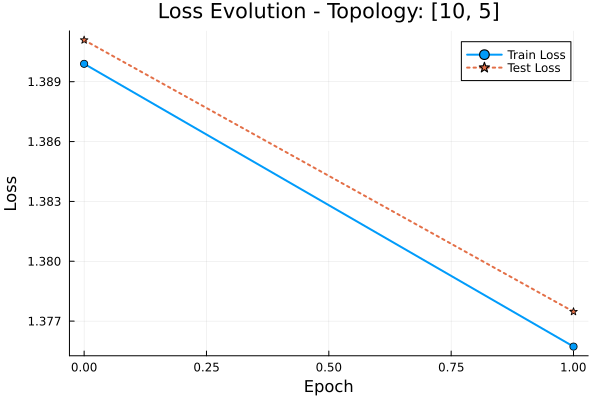

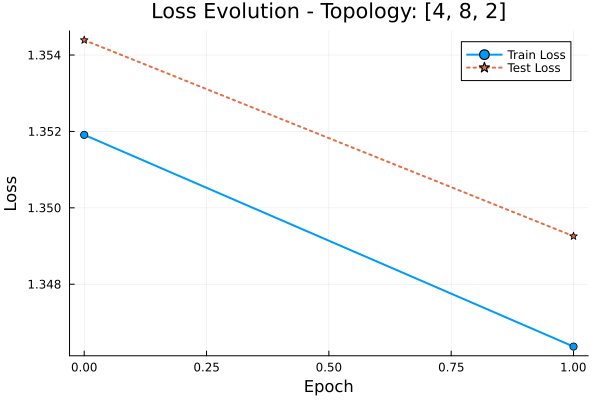

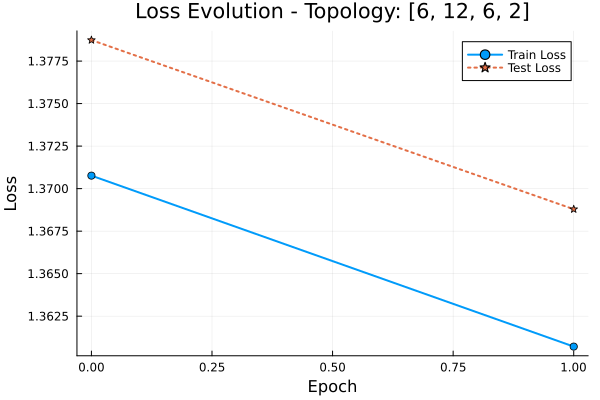

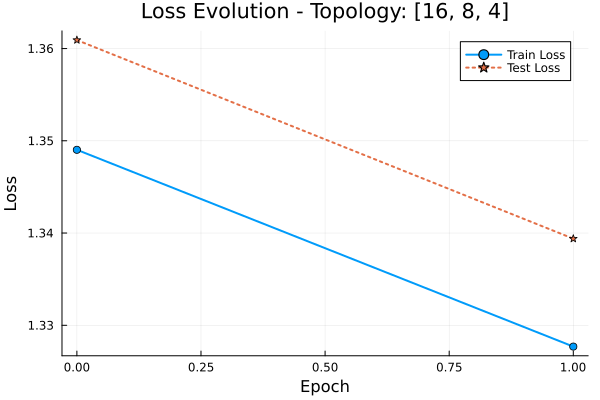

In [12]:
using Flux
using Statistics
using Plots


# --- Safe accuracy function ---
accuracy_score(pred::Vector{Int}, truth::Vector{Int}) = mean(pred .== truth)
accuracy = accuracy_score  # alias so trainClassANN can call accuracy(...)

# Alias for Flux losses
const Losses = Flux

architectures = [
    [10, 5],
    [4, 8, 2],
    [6, 12, 6, 2],
    [16, 8, 4]
]

# --- Store all results ---
results = Dict{String, Tuple{Vector{Float32}, Vector{Float32}, Vector{Float32}}}()

# Extract unique classes for one-hot encoding
classes = unique(trainingTargets)

for topology in architectures
    println("\nTraining architecture: ", topology)

    # One-hot encode the targets
    trainingTargetsOH = oneHotEncoding(trainingTargets, classes)
    # valTargetsOH      = oneHotEncoding(valTargets, classes)
    testTargetsOH     = oneHotEncoding(testTargets, classes)

    # Train the network
    finalAnn, trainLoss, valLoss, testLoss = trainClassANN(
        topology,
        (trainingInputs, trainingTargetsOH),
        # validationDataset = (valInputs, valTargetsOH),
        testDataset = (testInputs, testTargetsOH),
        maxEpochs = 1,
        learningRate = 0.01,
        showText = true
    )

    results[string(topology)] = (trainLoss, valLoss, testLoss)

    # --- Compute confusion matrix on test set ---
    testOutputs = finalAnn(testInputs')
    testPredictions = classifyOutputs(testOutputs')  # boolean matrix
    cm_metrics = confusionMatrix(testPredictions, testTargetsOH)

    println("\nConfusion matrix for architecture ", topology, ":")
    println(cm_metrics[end])  # last element is the actual confusion matrix
    #println("\ncm_metrics", cm_metrics, ":")
    # --- Pretty print ---
    println("\n================= MODEL PERFORMANCE =================")
    println("Architecture    : ", topology)
    println("Accuracy        : ", round(cm_metrics[1], digits=4))
    println("Error Rate      : ", round(cm_metrics[2], digits=4))
    println("Recall (Sens.)  : ", round(cm_metrics[3], digits=4))
    println("Specificity     : ", round(cm_metrics[4], digits=4))
    println("PPV (Precision) : ", round(cm_metrics[5], digits=4))
    println("NPV             : ", round(cm_metrics[6], digits=4))
    println("F1 Score        : ", round(cm_metrics[7], digits=4))
    println("=====================================================\n")

end

# --- Plotting all losses, one plot per model ---
for (topology, (trainLoss, valLoss, testLoss)) in results
    epochs = 0:length(trainLoss)-1  # include epoch 0

    p = plot(epochs, trainLoss, label="Train Loss", lw=2, marker=:circle)
    
    # if !isempty(valLoss)
    #     plot!(p, epochs, valLoss, label="Validation Loss", lw=2, linestyle=:dash, marker=:diamond)
    # end
    
    if !isempty(testLoss)
        plot!(p, epochs, testLoss, label="Test Loss", lw=2, linestyle=:dot, marker=:star)
    end

    xlabel!("Epoch")
    ylabel!("Loss")
    title!("Loss Evolution - Topology: $(topology)")
    plot!(legend=:topright)
    
    display(p)  # show the plot
end


## SVM/KNN/DT

In [13]:
using DataFrames
using MLJ
using CategoricalArrays
using MLJBase
import Logging
Logging.disable_logging(Logging.Info)

# ============================
# LOAD MODELS
# ============================
SVM        = @load SVC pkg = LIBSVM
DecisionTree = @load DecisionTreeClassifier pkg = DecisionTree verbosity=0
KNN        = @load KNNClassifier pkg = NearestNeighborModels verbosity=0

# ============================
# Function: Run models WITHOUT PCA
# ============================
function run_models_no_pca(trainingInputs, trainingTargetsCat,
                           testInputs, testTargetsCat)

    results = DataFrame(
        model   = String[],
        pca_dim = String[],       # use string label for pivot
        accuracy = Float64[]
    )

    println("\n===== Running models WITHOUT PCA =====")

    # Convert directly to DataFrames for MLJ
    train_df = DataFrame(trainingInputs, :auto)
    test_df  = DataFrame(testInputs, :auto)

    # Models to run
    models_dict = Dict(
        "SVM" => SVM(),
        "DT"  => DecisionTree(max_depth = 4),
        "KNN" => KNN()
    )

    # Train + evaluate
    for (name, model) in models_dict
        acc = train_and_evaluate(
            name, model,
            train_df, trainingTargetsCat,
            test_df,  testTargetsCat;
            verbose = false
        )
        push!(results, (name, "Raw", acc))
    end

    return results
end

# ============================
# RUN MODELS WITHOUT PCA
# ============================
# --- Convert targets to categorical ---
trainingTargetsCat = categorical(trainingTargets)
#valTargetsCat      = categorical(valTargets)
testTargetsCat      = categorical(testTargets)

raw_no_pca_results = run_models_no_pca(
    trainingInputs, trainingTargetsCat,
    testInputs, testTargetsCat
)

println("\n========== RAW RESULTS (NO PCA) ==========")
println(raw_no_pca_results)

# Pivot: rows=model, columns=pca_dim (here only "Raw"), values=accuracy
final_no_pca_report = unstack(raw_no_pca_results, :model, :pca_dim, :accuracy)

println("\n========== FINAL REPORT (NO PCA) ==========")
println(final_no_pca_report)
println("====================================================")


import MLJLIBSVMInterface ✔

===== Running models WITHOUT PCA =====

========== RAW RESULTS (NO PCA) ==========
3×3 DataFrame
 Row │ model   pca_dim  accuracy 
     │ String  String   Float64  
─────┼───────────────────────────
   1 │ SVM     Raw      0.935333
   2 │ DT      Raw      0.898
   3 │ KNN     Raw      0.912

========== FINAL REPORT (NO PCA) ==========
3×2 DataFrame
 Row │ model   Raw      
     │ String  Float64? 
─────┼──────────────────
   1 │ SVM     0.935333
   2 │ DT      0.898
   3 │ KNN     0.912


# Dimension Reduction (PCA)

## SVM/KNN/DT

In [14]:
using DataFrames
using MLJ
using CategoricalArrays
using MLJBase
import Logging
Logging.disable_logging(Logging.Info)

# ============================
# LOAD MODELS
# ============================
PCA        = @load PCA pkg = MultivariateStats
SVM        = @load SVC pkg = LIBSVM
DecisionTree = @load DecisionTreeClassifier pkg = DecisionTree verbosity=0
KNN        = @load KNNClassifier pkg = NearestNeighborModels verbosity=0

# ============================
# Function: Run PCA → Train → Evaluate
# ============================
function run_models_on_pca(trainingInputs, trainingTargetsCat,
                          testInputs, testTargetsCat, dims)

    # Raw results table
    results = DataFrame(
        model   = String[],
        pca_dim = Int[],
        accuracy = Float64[],
    )

    for outdim in dims
        println("\n===== Running PCA with maxoutdim = $outdim =====")

        # ------ Fit PCA ------
        pca_model = PCA(maxoutdim = outdim)
        pca_mach = machine(pca_model, MLJ.table(trainingInputs))
        MLJ.fit!(pca_mach)

        # Transform to matrix form
        pca_train = MLJBase.matrix(MLJ.transform(pca_mach, MLJ.table(trainingInputs)))
        pca_test  = MLJBase.matrix(MLJ.transform(pca_mach, MLJ.table(testInputs)))

        pca_train_df = DataFrame(pca_train, :auto)
        pca_test_df  = DataFrame(pca_test, :auto)

        # ------ Models to run ------
        models_dict = Dict(
            "SVM" => SVM(),
            "DT"  => DecisionTree(max_depth = 4),
            "KNN" => KNN()
        )

        # ------ Train + Evaluate ------
        for (name, model) in models_dict
            acc = train_and_evaluate(
                name, model,
                pca_train_df, trainingTargetsCat,
                pca_test_df,  testTargetsCat;
                verbose = false
            )

            push!(results, (name, outdim, acc))
        end
    end

    return results
end

# ============================
# RUN AND PIVOT RESULTS
# ============================
dims = [5, 6, 8]

# --- Convert targets to categorical ---
trainingTargetsCat = categorical(trainingTargets)
#valTargetsCat      = categorical(valTargets)
testTargetsCat      = categorical(testTargets)

raw_results = run_models_on_pca(
    trainingInputs, trainingTargetsCat,
    testInputs, testTargetsCat,
    dims
)

println("\n========== RAW RESULTS ==========")
println(raw_results)

# Pivot: rows=model, columns=pca_dim, values=accuracy
final_report = unstack(raw_results, :model, :pca_dim, :accuracy)

println("\n========== FINAL REPORT (MODEL  PCA-DIM) ==========")
println(final_report)
println("====================================================")


import MLJMultivariateStatsInterface ✔
import MLJLIBSVMInterface ✔

===== Running PCA with maxoutdim = 5 =====

===== Running PCA with maxoutdim = 6 =====

===== Running PCA with maxoutdim = 8 =====

========== RAW RESULTS ==========
9×3 DataFrame
 Row │ model   pca_dim  accuracy 
     │ String  Int64    Float64  
─────┼───────────────────────────
   1 │ SVM           5  0.925333
   2 │ DT            5  0.898
   3 │ KNN           5  0.916667
   4 │ SVM           6  0.927333
   5 │ DT            6  0.898667
   6 │ KNN           6  0.919333
   7 │ SVM           8  0.936
   8 │ DT            8  0.899333
   9 │ KNN           8  0.912667

========== FINAL REPORT (MODEL  PCA-DIM) ==========
3×4 DataFrame
 Row │ model   5         6         8        
     │ String  Float64?  Float64?  Float64? 
─────┼──────────────────────────────────────
   1 │ SVM     0.925333  0.927333  0.936
   2 │ DT      0.898     0.898667  0.899333
   3 │ KNN     0.916667  0.919333  0.912667


## ANN

In [13]:
function fit_pca(trainingInputs,testInputs,outdim)
    PCA = @load PCA pkg = MultivariateStats
    # ------ Fit PCA ------
    pca_model = PCA(maxoutdim = outdim)
    pca_mach = machine(pca_model, MLJ.table(trainingInputs))
    MLJ.fit!(pca_mach)

    # Transform to matrix form
    pca_train = MLJBase.matrix(MLJ.transform(pca_mach, MLJ.table(trainingInputs)))
    pca_test  = MLJBase.matrix(MLJ.transform(pca_mach, MLJ.table(testInputs)))
    return pca_train,pca_test
end

fit_pca (generic function with 1 method)

In [14]:
using Flux
using Statistics
using MLJBase
using DataFrames

# --- PCA transformation ---
pca_model = PCA(maxoutdim=5)
pca_mach = machine(pca_model, MLJ.table(trainingInputs))
MLJ.fit!(pca_mach)

pca_train = MLJBase.matrix(MLJ.transform(pca_mach, MLJ.table(trainingInputs)))  # num_samples × features
pca_val   = MLJBase.matrix(MLJ.transform(pca_mach, MLJ.table(valInputs)))
pca_test  = MLJBase.matrix(MLJ.transform(pca_mach, MLJ.table(testInputs)))

# --- One-hot encode targets (samples as rows) ---
classes = unique(trainingTargets)
trainingTargetsOH = oneHotEncoding(trainingTargets, classes)
valTargetsOH      = oneHotEncoding(valTargets, classes)
testTargetsOH     = oneHotEncoding(testTargets, classes)

# --- Training loop over architectures ---
architectures = [
    [10, 5],
    [4, 8, 2],
    [6, 12, 6, 2],
    [16, 8, 4]
]

results = Dict{String, Tuple{Vector{Float32}, Vector{Float32}, Vector{Float32}}}()

for topology in architectures
    println("\nTraining architecture: ", topology)

    finalAnn, trainLoss, valLoss, testLoss = trainClassANN(
        topology,
        (pca_train, trainingTargetsOH),
        validationDataset = (pca_val, valTargetsOH),
        testDataset       = (pca_test, testTargetsOH),
        maxEpochs = 5,
        learningRate = 0.01,
        showText = true
    )

    results[string(topology)] = (trainLoss, valLoss, testLoss)

    # --- Confusion metrics ---
    testOutputs = finalAnn(pca_test')
    testPredictions = classifyOutputs(testOutputs')  # rows = samples
    cm_metrics = confusionMatrix(testPredictions, testTargetsOH)

    println("\n================= MODEL PERFORMANCE =================")
    println("Architecture    : ", topology)
    println("Accuracy        : ", round(cm_metrics[1], digits=4))
    # println("Error Rate      : ", round(cm_metrics[2], digits=4))
    # println("Recall (Sens.)  : ", round(cm_metrics[3], digits=4))
    # println("Specificity     : ", round(cm_metrics[4], digits=4))
    # println("PPV (Precision) : ", round(cm_metrics[5], digits=4))
    # println("NPV             : ", round(cm_metrics[6], digits=4))
    # println("F1 Score        : ", round(cm_metrics[7], digits=4))
    # println("=====================================================\n")
end



Training architecture: [10, 5]
Epoch 0 - loss: 1.6385 - val_loss: 1.684 - test_loss: 1.6573
Epoch 1 - loss: 1.6089 - acc: 0.4155 - val_loss: 1.6526 - val_acc: 0.3847 - test_loss: 1.6274 - test_acc: 0.3947 - test_error: 0.6053 - epochsWithoutImprovement 0
Epoch 2 - loss: 1.5804 - acc: 0.4155 - val_loss: 1.6225 - val_acc: 0.3847 - test_loss: 1.5987 - test_acc: 0.3947 - test_error: 0.6053 - epochsWithoutImprovement 0
Epoch 3 - loss: 1.5531 - acc: 0.4155 - val_loss: 1.5935 - val_acc: 0.3847 - test_loss: 1.5712 - test_acc: 0.3947 - test_error: 0.6053 - epochsWithoutImprovement 0
Epoch 4 - loss: 1.5271 - acc: 0.4155 - val_loss: 1.5659 - val_acc: 0.3847 - test_loss: 1.545 - test_acc: 0.3947 - test_error: 0.6053 - epochsWithoutImprovement 0
Epoch 5 - loss: 1.5024 - acc: 0.4155 - val_loss: 1.5396 - val_acc: 0.3847 - test_loss: 1.52 - test_acc: 0.3947 - test_error: 0.6053 - epochsWithoutImprovement 0
The ANN corespond to the epoch 5

================= MODEL PERFORMANCE =================
Archite

In [15]:
using Flux
using Statistics
using MLJBase
using MLJ
using DataFrames

# --- PCA dimensions to test ---
pca_dims = [5, 6, 8]

# --- ANN architectures ---
architectures = [
    [10, 5],
    [4, 8, 2],
    [6, 12, 6, 2],
    [16, 8, 4]
]

# --- Prepare results container ---
# Dict[PCA_dim => Dict[architecture_str => (trainLoss, valLoss, testLoss, cm_metrics)]]
# ----------------------------
# Results dictionary
# Key: PCA dim -> Dict{Architecture string => (trainLoss, valLoss, testLoss, cm_metrics)}
# ----------------------------
results = Dict{Int, Dict{String, Tuple{Vector{Float32}, Vector{Float32}, Vector{Float32}, Tuple{Vararg{Any}}}}}()


# --- Unique classes for one-hot encoding ---
classes = unique(trainingTargets)
trainingTargetsOH = oneHotEncoding(trainingTargets, classes)
valTargetsOH      = oneHotEncoding(valTargets, classes)
testTargetsOH     = oneHotEncoding(testTargets, classes)

for dim in pca_dims
    println("\n===== PCA dimension = $dim =====")

    # --- Fit PCA ---
    pca_model = PCA(maxoutdim=dim)
    pca_mach = machine(pca_model, MLJ.table(trainingInputs))
    MLJ.fit!(pca_mach)

    # --- Transform data ---
    pca_train = MLJBase.matrix(MLJ.transform(pca_mach, MLJ.table(trainingInputs)))
    pca_val   = MLJBase.matrix(MLJ.transform(pca_mach, MLJ.table(valInputs)))
    pca_test  = MLJBase.matrix(MLJ.transform(pca_mach, MLJ.table(testInputs)))

    # --- Store results per architecture ---
    arch_results = Dict{String, Tuple{Vector{Float32}, Vector{Float32}, Vector{Float32}, Vector}}()

    for topology in architectures
        println("\nTraining architecture: ", topology)

        # --- Train ANN ---
        finalAnn, trainLoss, valLoss, testLoss = trainClassANN(
            topology,
            (pca_train, trainingTargetsOH),
            validationDataset = (pca_val, valTargetsOH),
            testDataset       = (pca_test, testTargetsOH),
            maxEpochs = 5,
            learningRate = 0.01,
            showText = true
        )

        # --- Confusion metrics ---
        testOutputs = finalAnn(pca_test')
        testPredictions = classifyOutputs(testOutputs')  # rows = samples
        cm_metrics = confusionMatrix(testPredictions, testTargetsOH)

        println("\nAccuracy for architecture ", topology, " PCA dim=", dim, ": ", round(cm_metrics[1], digits=4))

        # --- Store all results ---
        arch_results[string(topology)] = (trainLoss, valLoss, testLoss, cm_metrics)

        
    end

    results[dim] = arch_results
end

println("\n===== All results collected =====")



===== PCA dimension = 5 =====

Training architecture: [10, 5]
Epoch 0 - loss: 1.6823 - val_loss: 1.6417 - test_loss: 1.6564
Epoch 1 - loss: 1.646 - acc: 0.293 - val_loss: 1.6087 - val_acc: 0.3113 - test_loss: 1.6225 - test_acc: 0.298 - test_error: 0.702 - epochsWithoutImprovement 0
Epoch 2 - loss: 1.6116 - acc: 0.293 - val_loss: 1.5774 - val_acc: 0.3113 - test_loss: 1.5903 - test_acc: 0.298 - test_error: 0.702 - epochsWithoutImprovement 0
Epoch 3 - loss: 1.5789 - acc: 0.293 - val_loss: 1.5478 - val_acc: 0.3113 - test_loss: 1.5598 - test_acc: 0.298 - test_error: 0.702 - epochsWithoutImprovement 0
Epoch 4 - loss: 1.548 - acc: 0.293 - val_loss: 1.52 - val_acc: 0.3113 - test_loss: 1.5312 - test_acc: 0.298 - test_error: 0.702 - epochsWithoutImprovement 0
Epoch 5 - loss: 1.5192 - acc: 0.293 - val_loss: 1.4941 - val_acc: 0.3113 - test_loss: 1.5045 - test_acc: 0.298 - test_error: 0.702 - epochsWithoutImprovement 0
The ANN corespond to the epoch 5

Accuracy for architecture [10, 5] PCA dim=5: 

MethodError: MethodError: Cannot `convert` an object of type 
  Tuple{Float64, Float64, Float64, Float64, Float64, Float64, Float64, Matrix{Int64}} to an object of type 
  Vector
The function `convert` exists, but no method is defined for this combination of argument types.

Closest candidates are:
  convert(::Type{Vector}, !Matched::StatsBase.UnitWeights{T}) where T
   @ StatsBase C:\Users\gianp\.julia\packages\StatsBase\XgjIN\src\weights.jl:310
  convert(::Type{Vector}, !Matched::PooledArrays.PooledVector{T, R}) where {T, R}
   @ PooledArrays C:\Users\gianp\.julia\packages\PooledArrays\Vy2X0\src\PooledArrays.jl:509
  convert(::Type{Vector}, !Matched::StatsBase.AbstractWeights)
   @ StatsBase C:\Users\gianp\.julia\packages\StatsBase\XgjIN\src\weights.jl:30
  ...


In [16]:
using Flux
using Statistics
using MLJ
using MLJBase
using DataFrames

# ----------------------------
# PCA dimensions to test
# ----------------------------
pca_dims = [5, 6, 8]

# ----------------------------
# ANN architectures
# ----------------------------
architectures = [
    [10, 5],
    [4, 8, 2],
    [6, 12, 6, 2],
    [16, 8, 4]
]

# ----------------------------
# Prepare results container
# Dict[PCA_dim => Dict[architecture_str => (trainLoss, valLoss, testLoss, cm_metrics)]]
# ----------------------------
results = Dict{Int, Dict{String, Tuple{Vector{Float32}, Vector{Float32}, Vector{Float32}, Tuple{Vararg{Any}}}}}()

# ----------------------------
# One-hot encode targets (samples as rows)
# ----------------------------
classes = unique(trainingTargets)
trainingTargetsOH = oneHotEncoding(trainingTargets, classes)
valTargetsOH      = oneHotEncoding(valTargets, classes)
testTargetsOH     = oneHotEncoding(testTargets, classes)

# ----------------------------
# Loop over PCA dimensions
# ----------------------------
for dim in pca_dims
    println("\n===== PCA dimension = $dim =====")

    # --- Fit PCA ---
    pca_model = PCA(maxoutdim=dim)
    pca_mach  = machine(pca_model, MLJ.table(trainingInputs))
    MLJ.fit!(pca_mach)

    # --- Transform data ---
    pca_train = MLJBase.matrix(MLJ.transform(pca_mach, MLJ.table(trainingInputs)))
    pca_val   = MLJBase.matrix(MLJ.transform(pca_mach, MLJ.table(valInputs)))
    pca_test  = MLJBase.matrix(MLJ.transform(pca_mach, MLJ.table(testInputs)))

    # --- Store results per architecture ---
    arch_results = Dict{String, Tuple{Vector{Float32}, Vector{Float32}, Vector{Float32}, Tuple{Vararg{Any}}}}()

    for topology in architectures
        println("\nTraining architecture: ", topology)

        # --- Train ANN ---
        finalAnn, trainLoss, valLoss, testLoss = trainClassANN(
            topology,
            (pca_train, trainingTargetsOH),
            validationDataset = (pca_val, valTargetsOH),
            testDataset       = (pca_test, testTargetsOH),
            maxEpochs = 5,
            learningRate = 0.01,
            showText = true
        )

        # --- Compute confusion metrics ---
        testOutputs     = finalAnn(pca_test')            # shape: features × samples
        testPredictions = classifyOutputs(testOutputs')  # rows = samples
        cm_metrics      = confusionMatrix(testPredictions, testTargetsOH)

        println("\nAccuracy for architecture ", topology, " PCA dim=", dim, ": ", round(cm_metrics[1], digits=4))

        # --- Store all results ---
        arch_results[string(topology)] = (trainLoss, valLoss, testLoss, Tuple(cm_metrics))
    end

    # --- Save results for this PCA dim ---
    results[dim] = arch_results
end

println("\n===== All results collected =====")

# ----------------------------
# Optional: Print summary table of accuracies
# ----------------------------
println("\n===== Summary of Accuracies =====")
for (dim, arch_dict) in results
    for (arch, (_, _, _, metrics)) in arch_dict
        println("PCA dim=$dim | Architecture=$arch | Accuracy=$(round(metrics[1], digits=4))")
    end
end



===== PCA dimension = 5 =====

Training architecture: [10, 5]
Epoch 0 - loss: 1.3512 - val_loss: 1.3501 - test_loss: 1.3529
Epoch 1 - loss: 1.3316 - acc: 0.293 - val_loss: 1.3338 - val_acc: 0.3113 - test_loss: 1.3357 - test_acc: 0.298 - test_error: 0.702 - epochsWithoutImprovement 0
Epoch 2 - loss: 1.3146 - acc: 0.3005 - val_loss: 1.3202 - val_acc: 0.2907 - test_loss: 1.3212 - test_acc: 0.3 - test_error: 0.7 - epochsWithoutImprovement 0
Epoch 3 - loss: 1.3004 - acc: 0.4155 - val_loss: 1.3091 - val_acc: 0.3847 - test_loss: 1.3094 - test_acc: 0.3947 - test_error: 0.6053 - epochsWithoutImprovement 0
Epoch 4 - loss: 1.2889 - acc: 0.4155 - val_loss: 1.3005 - val_acc: 0.3847 - test_loss: 1.3002 - test_acc: 0.3947 - test_error: 0.6053 - epochsWithoutImprovement 0
Epoch 5 - loss: 1.2799 - acc: 0.4155 - val_loss: 1.2938 - val_acc: 0.3847 - test_loss: 1.2932 - test_acc: 0.3947 - test_error: 0.6053 - epochsWithoutImprovement 0
The ANN corespond to the epoch 5

Accuracy for architecture [10, 5] P